### Delta-Vega Hedging Option Position
Using Black-Scholes-Merton we can find the value of an option over time and we can evaluate our position 

We want to hedge a given position to construct a portfolio that is delta-vega neutral

We can analyze the changes in a day based on the stock movements and volatility movement to see if our hedging strategy worked

In [48]:
import matplotlib.pyplot as plt
import numpy as np
import scipy

In [49]:
def bsm_option(S, K, t, sigma, rf, type='put'):
    """
    S: Underlying asset value
    K: Strike price
    t: time-span of option (annualized)
    sigma: volatility
    rf: risk-free rate (annualized)
    type: type of written option
    """
    d1 = (np.log(S / K) + (rf + 0.5 * sigma**2) * t) / sigma / np.sqrt(t)
    d2 = d1 - sigma * np.sqrt(t)
    pdf_d1 = scipy.stats.norm.pdf(d1)
    
    if type.lower() == 'put':
        cdf_d1 = scipy.stats.norm.cdf(-d1)
        cdf_d2 = scipy.stats.norm.cdf(-d2)
        value = K * np.exp(-rf * t) * cdf_d2 - S * cdf_d1
        delta = - cdf_d1
        gamma = pdf_d1 / S / sigma / np.sqrt(t)
        theta = - S * sigma * pdf_d1 / 2 / np.sqrt(t) + rf * K * np.exp(-rf * t) * cdf_d2
        vega  = S * pdf_d1 * np.sqrt(t)
        rho   = - t * K * np.exp(-rf * t) * cdf_d2
        return {
            'type': type,
            'value': value,
            'delta': delta,
            'gamma': gamma,
            'theta': theta,
            'vega' : vega,
            'rho'  : rho,
            }

    if type.lower() == 'call':
        cdf_d1 = scipy.stats.norm.cdf(d1)
        cdf_d2 = scipy.stats.norm.cdf(d2)
        value = S * cdf_d1 - K * np.exp(-rf * t) * cdf_d2
        delta = cdf_d1
        gamma = pdf_d1 / S / sigma / np.sqrt(t)
        theta = - S * sigma * pdf_d1 / 2 / np.sqrt(t) - rf * K * np.exp(-rf * t) * cdf_d2
        vega  = S * pdf_d1 * np.sqrt(t)
        rho   = t * K * np.exp(-rf * t) * cdf_d2
        return {
            'type': type,
            'value': value,
            'delta': delta,
            'gamma': gamma,
            'theta': theta,
            'vega' : vega,
            'rho'  : rho,
            }

In [50]:
# We are considering the following option
t1 = 90/365
S = 60
K1 = 60
rf = 0.08
sigma = 0.3
typeOption = 'call'

option1 = bsm_option(S, K1, t1, sigma, rf, type=typeOption)
option1

{'type': 'call',
 'value': np.float64(4.1445229602782945),
 'delta': np.float64(0.5819565966075844),
 'gamma': np.float64(0.043688491714200604),
 'theta': np.float64(-9.539365484594638),
 'vega': np.float64(11.634305190740545),
 'rho': np.float64(7.587831658235366)}

Suppose we write z = -1000 call options

To build our portfolio we consider another option with the following features

In [51]:
t2 = 60/365
S = 60
K2 = 65
rf = 0.08
sigma = 0.3
typeOption = 'call'

option2 = bsm_option(S, K2, t2, sigma, rf, type=typeOption)
option2

{'type': 'call',
 'value': np.float64(1.3782577171980002),
 'delta': np.float64(0.3123732423647997),
 'gamma': np.float64(0.04850151859857283),
 'theta': np.float64(-9.246376958943998),
 'vega': np.float64(8.610680562157588),
 'rho': np.float64(2.854378656113422)}

In [52]:
z = -1000
z_hat = -z * option1['vega'] / option2['vega']
x = -z * option1['delta'] - z_hat * option2['delta']
y = -x * S - z * option1['value'] - z_hat * option2['value']

print(f'(x, y, z, z_hat) = ({round(x, 2)}, {round(y, 2)}, {round(z, 2)}, {round(z_hat, 2)})')


(x, y, z, z_hat) = (159.89, -7311.35, -1000, 1351.15)


### Delta Hedging Option Position
Using Black-Scholes-Merton we can find the value of an option over time and we can evaluate our position 

We want to hedge a given position to construct a portfolio that is delta neutral

We can analyze the changes in a day based on the stock movements or changes in parameters such as volatility and risk-free rate

$$
\begin{align}
V(S) &= x \cdot S + y + z \cdot D_1 + \hat{z} \cdot D_2 \\
\Delta_V &= x + z \cdot \Delta_{D_1} + \hat{z} \cdot \Delta_{D_2} \\
V_V &= z \cdot V_{D_1} + \hat{z} \cdot V_{D_2}
\end{align}
$$

We set $\Delta_V = 0$ and $V_V = 0$ in order do obtain delta-vega neutrality

$$
\begin{align}
\hat{z} &=  -z \cdot \frac{V_{D_1}}{V_{D_2}} \sim 1351.15\\
x &= -z \cdot \Delta_{D_1} + \hat{z} \cdot \Delta_{D_2} \sim 159.89
\end{align}
$$

In addition we can find money position $y$ so that the value of the portfolio is zero

$$
\begin{align}
0 &= x \cdot S + y + z \cdot D_1 + \hat{z} \cdot D_2 \\
y &= -x \cdot S - z \cdot D_1 - \hat{z} \cdot D_2 \sim -7311.35
\end{align}
$$

In [53]:
def portfolio_position(S, K1, K2, t1, t2, sigma, rf, typeOption, daysPassed, x, y, z, z_hat):
    daysRemaining_1 = t1 - daysPassed
    daysRemaining_2 = t2 - daysPassed
    valueStocks = x * S
    valueCash = y * np.exp(rf * daysPassed)
    valueOptions_1 = bsm_option(S, K1, daysRemaining_1, sigma, rf, typeOption)['value']
    valueOptions_2 = bsm_option(S, K2, daysRemaining_2, sigma, rf, typeOption)['value']
    return valueStocks + valueCash + z * valueOptions_1 + z_hat * valueOptions_2

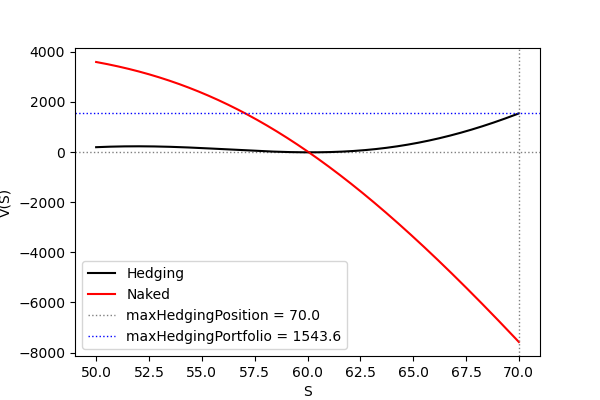

In [54]:
# Analysis of portfolio after 1 day, 89 days remaining
daysPassed = 1/365

# Potential stock values
stockValues = np.linspace(50, 70, 2001)

x, y, z, z_hat = 159.89, -7311.35, -1000, 1351.15
hedgingPosition = [portfolio_position(S, K1, K2, t1, t2, sigma, rf, typeOption, daysPassed, x, y, z, z_hat) for S in stockValues]

x, y, z, z_hat = 0, 4144.52, -1000, 0
nakedPosition = [portfolio_position(S, K1, K2, t1, t2, sigma, rf, typeOption, daysPassed, x, y, z, z_hat) for S in stockValues]


fig, ax = plt.subplots(1, 1, figsize=(6,4))
ax.plot(stockValues, hedgingPosition, color='black', label='Hedging')
ax.plot(stockValues, nakedPosition, color='red', label='Naked')

maxHedgingPosition = stockValues[np.argmax(hedgingPosition)]
maxHedgingPortfolio = np.max(hedgingPosition)
ax.axvline(maxHedgingPosition, lw=1, ls=':', color='grey', label=f'maxHedgingPosition = {round(maxHedgingPosition, 2)}')
ax.axhline(maxHedgingPortfolio, lw=1, ls=':', color='blue', label=f'maxHedgingPortfolio = {round(maxHedgingPortfolio, 2)}')
ax.axhline(0, lw=1, ls=':', color='black', alpha=0.5)
ax.set_xlabel('S')
ax.set_ylabel('V(S)')
ax.legend()
plt.show()

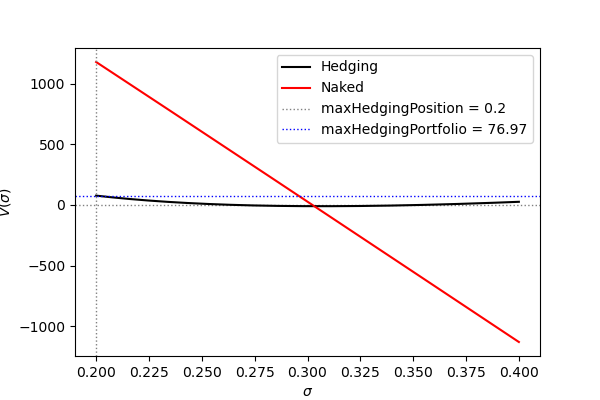

In [55]:
# Analysis of portfolio after 1 day, 89 days remaining
daysPassed = 1/365

# Potential sigma values
S = 60
sigmaValues = np.linspace(0.2, 0.4, 2001)

x, y, z, z_hat = 159.89, -7311.35, -1000, 1351.15
hedgingPosition = [portfolio_position(S, K1, K2, t1, t2, sigma, rf, typeOption, daysPassed, x, y, z, z_hat) for sigma in sigmaValues]

x, y, z, z_hat = 0, 4144.52, -1000, 0
nakedPosition = [portfolio_position(S, K1, K2, t1, t2, sigma, rf, typeOption, daysPassed, x, y, z, z_hat) for sigma in sigmaValues]


fig, ax = plt.subplots(1, 1, figsize=(6,4))
ax.plot(sigmaValues, hedgingPosition, color='black', label='Hedging')
ax.plot(sigmaValues, nakedPosition, color='red', label='Naked')

maxHedgingPosition = sigmaValues[np.argmax(hedgingPosition)]
maxHedgingPortfolio = np.max(hedgingPosition)
ax.axvline(maxHedgingPosition, lw=1, ls=':', color='grey', label=f'maxHedgingPosition = {round(maxHedgingPosition, 2)}')
ax.axhline(maxHedgingPortfolio, lw=1, ls=':', color='blue', label=f'maxHedgingPortfolio = {round(maxHedgingPortfolio, 2)}')
ax.axhline(0, lw=1, ls=':', color='black', alpha=0.5)
ax.set_xlabel(r'$\sigma$')
ax.set_ylabel(r'$V(\sigma)$')
ax.legend()
plt.show()

In [63]:
import numpy as np
import plotly.graph_objects as go

stock_values = np.linspace(50, 70, 41)
sigma_values = np.linspace(0.20, 0.40, 21)

S_grid, sigma_grid = np.meshgrid(stock_values, sigma_values)

x, y, z, z_hat = 159.89, -7311.35, -1000, 1351.15
hedging_position = np.array([[portfolio_position(S, K1, K2, t1, t2, sigma, rf, typeOption, daysPassed, x, y, z, z_hat ) for S in stock_values] for sigma in sigma_values])

fig = go.Figure(
    data=[
        go.Surface(
        x=S_grid,
        y=sigma_grid,
        z=hedging_position
    )]
)

fig.update_layout(
    title="Delta-Vega Hedging",
    scene=dict(
        xaxis_title="S",
        yaxis_title="σ",
        zaxis_title="V(S, σ)"
    )
)

fig.show()

`Naked position`: Great movements of the stock price and volatility may lead to big gains and even bigger losses

`Hedged position` (delta-vega neutral): There is a large region of stock price movement and a region of volatility change that makes our portfolio safe (the flat region around S = 60 for stock price and volatility sigma = 30), in this region the portfolio is highly protected. In addition we can notice that different combinations of stock price and volatility can lead to gain and losses even with delta-vega hedging
